In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")

print("Path to dataset files:", path)

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from dataclasses import dataclass

# Preprocess Data

In [2]:
df = pd.read_csv("/kaggle/input/hourly-energy-consumption/AEP_hourly.csv")

In [ ]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").drop_duplicates("Datetime")
df = df.set_index("Datetime")

target_col = df.columns[0]

# Ensure hourly index (this will create missing hours if any)
df = df.asfreq("h")

print(df.isna().sum())

AEP_MW    27
dtype: int64


In [4]:
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print(train_df.index.min(), train_df.index.max(), len(train_df))
print(val_df.index.min(), val_df.index.max(), len(val_df))
print(test_df.index.min(), test_df.index.max(), len(test_df))

2004-10-01 01:00:00 2014-06-08 19:00:00 84907
2014-06-08 20:00:00 2016-07-05 21:00:00 18194
2016-07-05 22:00:00 2018-08-03 00:00:00 18195


In [5]:
def fill_split(x: pd.DataFrame) -> pd.DataFrame:
    return x.ffill().bfill()

train_df = fill_split(train_df)
val_df   = fill_split(val_df)
test_df  = fill_split(test_df)

In [ ]:
def add_time_features(x: pd.DataFrame) -> pd.DataFrame:
    x = x.copy()
    x["hour"] = x.index.hour
    x["dayofweek"] = x.index.dayofweek
    x["month"] = x.index.month
    return x

train_df = add_time_features(train_df)
val_df   = add_time_features(val_df)
test_df  = add_time_features(test_df)

feature_cols = [target_col, "hour", "dayofweek", "month"]

In [7]:
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(train_df[feature_cols].values)  # TRAIN ONLY

I0000 00:00:1770715976.952744      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770715976.958547      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
LOOKBACK = 168
HORIZON  = 24
BATCH    = 64

def make_seq2seq_windows(df):
    """
    Returns:
      X_enc: (N, LOOKBACK, F) normalized
      X_dec: (N, HORIZON, 1)  decoder input (teacher forcing), normalized target
      y_out: (N, HORIZON, 1)  decoder target, normalized target
    """
    # encoder input features (normalized)
    X_all = df[feature_cols].values.astype(np.float32)
    X_all = normalizer(X_all).numpy()

    # raw target
    y_all = df[target_col].values.astype(np.float32)

    # normalize target using TRAIN stats ONLY
    y_mean = train_df[target_col].mean()
    y_std  = train_df[target_col].std()
    y_norm = ((y_all - y_mean) / (y_std + 1e-6)).astype(np.float32)

    n = len(df)
    n_starts = n - LOOKBACK - HORIZON + 1
    if n_starts <= 0:
        raise ValueError(f"Need at least {LOOKBACK+HORIZON} rows, got {n}")

    X_enc = np.stack([X_all[i:i+LOOKBACK] for i in range(n_starts)], axis=0)  # (N,L,F)

    # y_future = y(t+1 ... t+H)
    y_future = np.stack([y_norm[i+LOOKBACK : i+LOOKBACK+HORIZON] for i in range(n_starts)], axis=0)  # (N,H)

    # decoder input is shifted right with 0 at start: [0, y(t+1), ..., y(t+H-1)]
    dec_in = np.zeros_like(y_future)
    dec_in[:, 1:] = y_future[:, :-1]

    # expand to (N,H,1)
    X_dec = dec_in[..., None]
    y_out = y_future[..., None]
    return X_enc, X_dec, y_out


Xenc_train, Xdec_train, yout_train = make_seq2seq_windows(train_df)
Xenc_val,   Xdec_val,   yout_val   = make_seq2seq_windows(val_df)
Xenc_test,  Xdec_test,  yout_test  = make_seq2seq_windows(test_df)

train_ds = tf.data.Dataset.from_tensor_slices(((Xenc_train, Xdec_train), yout_train)) \
    .shuffle(10000).batch(BATCH).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(((Xenc_val, Xdec_val), yout_val)) \
    .batch(BATCH).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(((Xenc_test, Xdec_test), yout_test)) \
    .batch(BATCH).prefetch(tf.data.AUTOTUNE)

print("Encoder:", Xenc_train.shape, "Decoder-in:", Xdec_train.shape, "y:", yout_train.shape)

Encoder: (84716, 168, 4) Decoder-in: (84716, 24, 1) y: (84716, 24, 1)


# Model

In [47]:
class SinusoidalPositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, d_model, max_len=5000, **kwargs):
        super().__init__(**kwargs)
        self.d_model = int(d_model)
        self.max_len = int(max_len)

        pos = np.arange(self.max_len)[:, None]
        i = np.arange(self.d_model)[None, :]
        angle_rates = 1 / np.power(10000, (2*(i//2)) / np.float32(self.d_model))
        angles = pos * angle_rates

        pe = np.zeros((self.max_len, self.d_model), dtype=np.float32)
        pe[:, 0::2] = np.sin(angles[:, 0::2])
        pe[:, 1::2] = np.cos(angles[:, 1::2])
        self.pe = tf.constant(pe[None, :, :])  # (1, max_len, d_model)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pe[:, :seq_len, :]

def causal_attention_mask(seq_len):
    # shape: (1, seq_len, seq_len) broadcastable over batch and heads
    mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
    return mask[None, :, :]

In [48]:
def encoder_block(d_model, num_heads, ff_dim, dropout=0.1):
    x_in = tf.keras.Input(shape=(None, d_model))

    attn = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model//num_heads, dropout=dropout
    )(x_in, x_in)

    x = tf.keras.layers.Dropout(dropout)(attn)
    x = tf.keras.layers.Add()([x_in, x])
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)

    ff = tf.keras.layers.Dense(ff_dim, activation="relu")(x)
    ff = tf.keras.layers.Dropout(dropout)(ff)
    ff = tf.keras.layers.Dense(d_model)(ff)

    x2 = tf.keras.layers.Add()([x, ff])
    x2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x2)

    return tf.keras.Model(x_in, x2)


def decoder_block(d_model, num_heads, ff_dim, dropout=0.1):
    dec_in = tf.keras.Input(shape=(None, d_model))
    enc_out = tf.keras.Input(shape=(None, d_model))

    # masked self-attention
    seq_len = HORIZON
    mask = causal_attention_mask(seq_len)

    self_attn = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model//num_heads, dropout=dropout
    )(dec_in, dec_in, attention_mask=mask)

    x = tf.keras.layers.Dropout(dropout)(self_attn)
    x = tf.keras.layers.Add()([dec_in, x])
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)

    # cross-attention (decoder attends to encoder memory)
    cross_attn = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model//num_heads, dropout=dropout
    )(x, enc_out)

    x2 = tf.keras.layers.Dropout(dropout)(cross_attn)
    x2 = tf.keras.layers.Add()([x, x2])
    x2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x2)

    # FFN
    ff = tf.keras.layers.Dense(ff_dim, activation="relu")(x2)
    ff = tf.keras.layers.Dropout(dropout)(ff)
    ff = tf.keras.layers.Dense(d_model)(ff)

    out = tf.keras.layers.Add()([x2, ff])
    out = tf.keras.layers.LayerNormalization(epsilon=1e-6)(out)

    return tf.keras.Model([dec_in, enc_out], out)

In [49]:
def build_seq2seq_transformer(
    lookback, num_features, horizon,
    d_model=64, num_heads=4, ff_dim=128, num_enc_layers=2, num_dec_layers=2, dropout=0.1
):
    # encoder inputs: (B, LOOKBACK, F)
    enc_inputs = tf.keras.Input(shape=(lookback, num_features), name="enc_inputs")

    # decoder inputs: (B, H, 1) normalized target shifted
    dec_inputs = tf.keras.Input(shape=(horizon, 1), name="dec_inputs")

    # project to d_model
    enc = tf.keras.layers.Dense(d_model)(enc_inputs)
    enc = SinusoidalPositionalEncoding(d_model)(enc)

    for _ in range(num_enc_layers):
        enc = encoder_block(d_model, num_heads, ff_dim, dropout)(enc)

    dec = tf.keras.layers.Dense(d_model)(dec_inputs)
    dec = SinusoidalPositionalEncoding(d_model)(dec)

    for _ in range(num_dec_layers):
        dec = decoder_block(d_model, num_heads, ff_dim, dropout)([dec, enc])

    # output per decoder timestep
    out = tf.keras.layers.Dense(1, name="y_hat")(dec)  # (B,H,1)
    return tf.keras.Model([enc_inputs, dec_inputs], out)


model = build_seq2seq_transformer(
    lookback=LOOKBACK,
    num_features=len(feature_cols),
    horizon=HORIZON,
    d_model=64, num_heads=4, ff_dim=128,
    num_enc_layers=2, num_dec_layers=2,
    dropout=0.1
)

model.summary()

Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ enc_inputs          │ (None, 168, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 168, 64)   │        320 │ enc_inputs[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_inputs          │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sinusoidal_positio… │ (None, 168, 64)   │          0 │ dense_52[0][0]    │
│ (SinusoidalPositio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_57 (Dense)    │ (None, 24, 64)    │        128 │ dec_inputs[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_24       │ (None, 168, 64)   │     33,472 │ sinusoidal_posit… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sinusoidal_positio… │ (None, 24, 64)    │          0 │ dense_57[0][0]    │
│ (SinusoidalPositio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_25       │ (None, 168, 64)   │     33,472 │ functional_24[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_26       │ (None, 24, 64)    │     50,240 │ sinusoidal_posit… │
│ (Functional)        │                   │            │ functional_25[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_27       │ (None, 24, 64)    │     50,240 │ functional_26[0]… │
│ (Functional)        │                   │            │ functional_25[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y_hat (Dense)       │ (None, 24, 1)     │         65 │ functional_27[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 167,937 (656.00 KB)

 Trainable params: 167,937 (656.00 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [50]:
def mae_metric(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.Huber(),
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
)

ckpt_path = "best_seq2seq.keras"
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_mae", mode="min", factor=0.5, patience=5, verbose=1
    )
]

In [51]:
EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
1324/1324 ━━━━━━━━━━━━━━━━━━━━ 70s 32ms/step - loss: 0.0735 - mae: 0.2357 - val_loss: 0.0040 - val_mae: 0.0683 - learning_rate: 0.0010
Epoch 2/30
1324/1324 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - loss: 0.0062 - mae: 0.0852 - val_loss: 0.0027 - val_mae: 0.0553 - learning_rate: 0.0010
Epoch 3/30
1324/1324 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - loss: 0.0042 - mae: 0.0697 - val_loss: 0.0021 - val_mae: 0.0482 - learning_rate: 0.0010
Epoch 4/30
1324/1324 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - loss: 0.0033 - mae: 0.0613 - val_loss: 0.0022 - val_mae: 0.0496 - learning_rate: 0.0010
Epoch 5/30
1324/1324 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - loss: 0.0028 - mae: 0.0564 - val_loss: 0.0019 - val_mae: 0.0459 - learning_rate: 0.0010
Epoch 6/30
1324/1324 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - loss: 0.0024 - mae: 0.0527 - val_loss: 0.0018 - val_mae: 0.0444 - learning_rate: 0.0010
Epoch 7/30
1324/1324 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - loss: 0.0022 - mae: 0.0505 - val_loss: 0.0015 - val_mae: 0.0410 - 

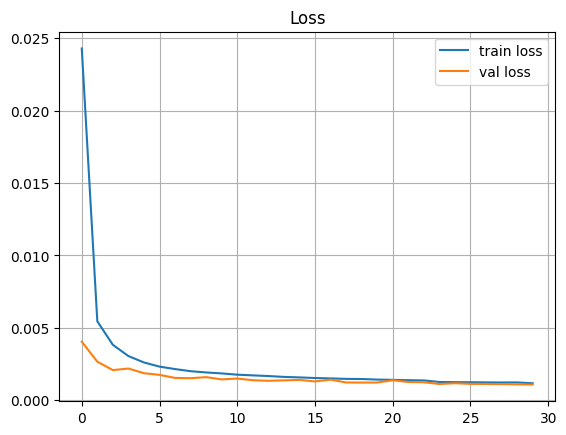

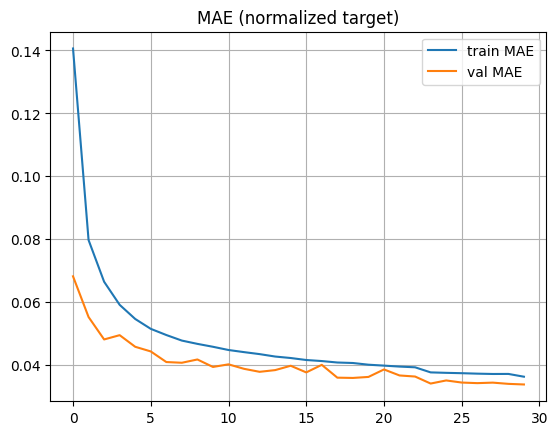

In [52]:
hist = history.history

import matplotlib.pyplot as plt

plt.figure()
plt.plot(hist["loss"], label="train loss")
plt.plot(hist["val_loss"], label="val loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(hist["mae"], label="train MAE")
plt.plot(hist["val_mae"], label="val MAE")
plt.title("MAE (normalized target)")
plt.legend()
plt.grid(True)
plt.show()

## Evaluation & Inference

In [53]:
test_metrics = model.evaluate(test_ds, verbose=1)
print(dict(zip(model.metrics_names, test_metrics)))

282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0011 - mae: 0.0358
{'loss': 0.001175740617327392, 'compile_metrics': 0.03637833520770073}


In [ ]:
y_mean = train_df[target_col].mean()
y_std  = train_df[target_col].std() + 1e-6

def make_encoder_input_from_df(df_window):
    """
    df_window: DataFrame with exactly LOOKBACK rows and columns feature_cols
    returns: X_enc (1, LOOKBACK, F) normalized
    """
    X = df_window[feature_cols].values.astype(np.float32)
    X = normalizer(X).numpy()
    return X[None, :, :]

def predict_24h_autoregressive(best_model, df, start_pos, lookback=168, horizon=24):
    # encoder window
    enc_window = df.iloc[start_pos : start_pos + lookback]
    X_enc = make_encoder_input_from_df(enc_window)  # (1,L,F)

    # ground truth for plotting
    true_mw = df.iloc[start_pos + lookback : start_pos + lookback + horizon][target_col].values.astype(np.float32)

    # decoder inputs in NORMALIZED target space
    dec_in = np.zeros((1, horizon, 1), dtype=np.float32)  # (1,H,1)

    # iterative decoding
    for t in range(horizon):
        y_hat_seq = best_model.predict([X_enc, dec_in], verbose=0)  # (1,H,1)
        y_hat_t = y_hat_seq[0, t, 0]  # normalized prediction at step t

        if t + 1 < horizon:
            dec_in[0, t+1, 0] = y_hat_t  # feed prediction forward

    # final prediction sequence (normalized) is last forward pass output
    y_pred_norm = y_hat_seq[0, :, 0]

    # inverse transform to MW
    pred_mw = y_pred_norm * y_std + y_mean
    return pred_mw.astype(np.float32), true_mw

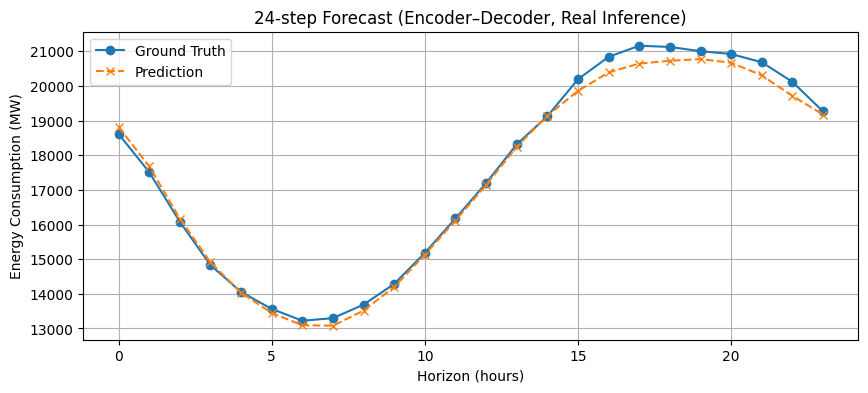

In [ ]:
start_pos = 0

pred_24, true_24 = predict_24h_autoregressive(model, test_df, start_pos, LOOKBACK, HORIZON)

plt.figure(figsize=(10,4))
plt.plot(true_24, label="Ground Truth", marker="o")
plt.plot(pred_24, label="Prediction", marker="x", linestyle="--")
plt.title("24-step Forecast (Encoder–Decoder, Real Inference)")
plt.xlabel("Horizon (hours)")
plt.ylabel("Energy Consumption (MW)")
plt.legend()
plt.grid(True)
plt.show()